# RL - Chapter 6 - TD - Random Walk Problem


In [186]:
from toc import generate_toc

path = 'ch_6_TD_p1_random_walk.ipynb'
generate_toc(path)

## Table of Contents

- [RL - Chapter 6 - TD - Random Walk Problem](#rl-chapter-6-td-random-walk-problem)
  - [Random Walk environment](#random-walk-environment)
  - [constant alpha MC method](#constant-alpha-mc-method)
  - [Results](#results)
  - [Batch Update](#batch-update)

In [187]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# set decimal precision for numpy arrays
np.set_printoptions(precision=1, suppress=True)

## constant alpha MC method


In [189]:
# constant-alpha MC method for prediction
class MonteCarloControl:
    def __init__(self, gamma=1.0, alpha=0.1, n_episodes=100):
        self.gamma = gamma
        self.alpha = alpha
        self.n_episodes = n_episodes

        # Initialize Returns
        self.n_states = 6
        self.V = np.ones(self.n_states) * 0.5
        self.V[0] = 0
        self.V[-1] = 0
        self.true_v = np.linspace(0, 1, self.n_states)
        self.true_v[0] = 0
        self.true_v[-1] = 0
        self.rms_error = []

    def run_batch_prediction(self, tol=1e-1, max_sweeps=10_000, normalize_by_visits=True):
        episodes = []
        for _ in range(self.n_episodes):
            episode_data = self.generate_episode()
            episodes.append(episode_data)

            # batch update over all episodes so far
            for _sweep in range(max_sweeps):
                delta = 0.0
                updates = np.zeros_like(self.V, dtype=float)
                visit_counts = np.zeros_like(self.V, dtype=float)

                # calculate updates over all episodes
                for episode in episodes:
                    G = 0.0
                    for state, reward in reversed(episode):
                        G = self.gamma * G + reward
                        updates[state] += (G - self.V[state])
                        visit_counts[state] += 1.0

                # update value function (non-terminal states only)
                for s in range(1, self.n_states - 1):
                    if normalize_by_visits and visit_counts[s] > 0:
                        step = updates[s] / visit_counts[s]
                    else:
                        step = updates[s]
                    change = self.alpha * step
                    self.V[s] += change
                    delta = max(delta, abs(change))

                if delta < tol:
                    break

            # calculate RMS error
            error = np.sqrt(np.mean((self.V[1:-1] - self.true_v[1:-1]) ** 2))
            self.rms_error.append(error)

    def run_prediction(self):
        for e in range(self.n_episodes):
            episode_data = self.generate_episode()
            G = 0
            for state, reward in reversed(episode_data):
                G = self.gamma * G + reward
                self.V[state] += self.alpha * (G - self.V[state])
            # calculate RMS error
            error = np.sqrt(np.mean((self.V[1:-1] - self.true_v[1:-1]) ** 2))
            self.rms_error.append(error)

    def generate_episode(self):
        # start from the middle state
        state = 3
        episode = []  # list of (state, reward) pairs

        while True:
            # choose action based on policy (uniform random)
            action = np.random.choice([0, 1])  # 0: left, 1: right
            state = state + (1 if action == 1 else -1)
            if state == self.n_states - 1:
                episode.append((state, 1))
                break
            episode.append((state, 0))
            if state == 0:
                break
        return episode

In [190]:
# Tabular TD(0)
class TD0:
    def __init__(self, gamma=1.0, alpha=0.1, n_episodes=100):
        self.gamma = gamma
        self.alpha = alpha
        self.n_episodes = n_episodes

        # Initialize Returns
        self.n_states = 6
        self.V = np.ones(self.n_states) * 0.5
        self.V[0] = 0
        self.V[-1] = 0
        self.true_v = np.linspace(0, 1, self.n_states)
        self.rms_error = []

    def run_batch_prediction(self, tol=1e-1, max_sweeps=10_000, normalize_by_visits=True):
        episodes = []
        for _ in range(self.n_episodes):
            state = 3  # start from the middle state
            episode = []  # list of (state, reward, next_state) triples
            while True:
                action = np.random.choice([0, 1])  # 0: left, 1: right
                next_state = state + (1 if action == 1 else -1)
                reward = 1 if next_state == self.n_states - 1 else 0
                episode.append((state, reward, next_state))
                state = next_state
                if reward == 1 or state == 0:
                    break
            episodes.append(episode)

            # --- batch TD sweeps until convergence (or cap) ---
            for _sweep in range(max_sweeps):
                delta = 0.0
                updates = np.zeros_like(self.V, dtype=float)
                visit_counts = np.zeros_like(self.V, dtype=float)

                for ep in episodes:
                    for (s, r, s_next) in ep:
                        td_error = r + self.gamma * self.V[s_next] - self.V[s]
                        updates[s] += td_error
                        visit_counts[s] += 1.0

                # apply updates (non-terminal states only)
                for s in range(1, self.n_states - 1):
                    if normalize_by_visits and visit_counts[s] > 0:
                        step = updates[s] / visit_counts[s]
                    else:
                        step = updates[s]
                    change = self.alpha * step
                    self.V[s] += change
                    delta = max(delta, abs(change))

                if delta < tol:
                    break

            # RMS error
            error = np.sqrt(np.mean((self.V[1:-1] - self.true_v[1:-1]) ** 2))
            self.rms_error.append(error)

    def run_prediction(self):
        for e in range(self.n_episodes):
            state = 3  # start from the middle state
            while True:
                action = np.random.choice([0, 1])  # 0: left, 1: right
                next_state = state + (1 if action == 1 else -1)
                reward = 1 if next_state == self.n_states - 1 else 0
                # TD(0) update
                self.V[state] += self.alpha * (reward + self.gamma * self.V[next_state] - self.V[state])
                state = next_state
                if reward == 1 or state == 0:
                    break
            # calculate RMS error
            error = np.sqrt(np.mean((self.V[1:-1] - self.true_v[1:-1]) ** 2))
            self.rms_error.append(error)

## Results


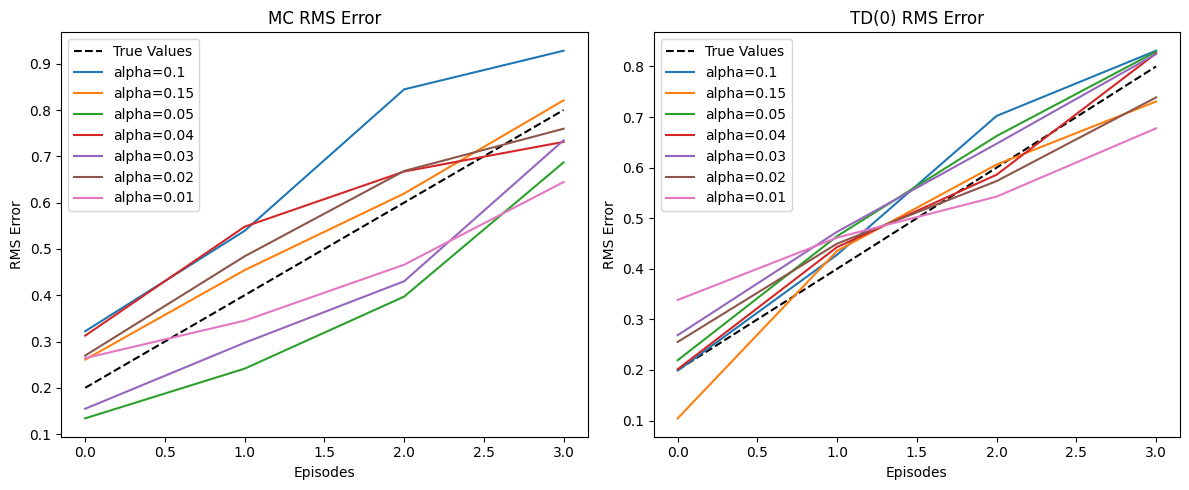

In [191]:
# plot RMS error over episodes for both methods
alphas_1 = [0.1, 0.15, 0.05, 0.04, 0.03, 0.02, 0.01]
alphas_2 = [0.1, 0.15, 0.05, 0.04, 0.03, 0.02, 0.01]
# alphas_2 = [0.1, 0.15, 0.05]

mc_v_epiods = []
td_v_epiods = []
for alpha in alphas_1:
    mc = MonteCarloControl(alpha=alpha)
    mc.run_prediction()
    mc_v_epiods.append(mc.V[1:-1].copy())

for alpha in alphas_2:
    td0 = TD0(alpha=alpha)
    td0.run_prediction()
    td_v_epiods.append(td0.V[1:-1].copy())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# plot true values
ax[0].plot(mc.true_v[1:-1], label='True Values', linestyle='--', color='black')
ax[1].plot(td0.true_v[1:-1], label='True Values', linestyle='--', color='black')
# plot estimated values for MC and TD(0)
for i, alpha in enumerate(alphas_1):
    ax[0].plot(mc_v_epiods[i], label=f'alpha={alpha}')
for i, alpha in enumerate(alphas_2):
    ax[1].plot(td_v_epiods[i], label=f'alpha={alpha}')
ax[0].set_title('MC RMS Error')
ax[1].set_title('TD(0) RMS Error')
for a in ax:
    a.set_xlabel('Episodes')
    a.set_ylabel('RMS Error')
    a.legend()
plt.tight_layout()
plt.show()

In [192]:
# rms over 100 run of 100 episodes for each alpha
mc_rms_errors = []
td_rms_errors = []
for alpha in alphas_1:
    rms = np.zeros(100)
    for _ in range(100):
        mc_control = MonteCarloControl(gamma=1.0, alpha=alpha, n_episodes=100)
        mc_control.run_prediction()
        rms += np.array(mc_control.rms_error)
    rms /= 100
    mc_rms_errors.append(rms)

for alpha in alphas_2:
    # TD(0) results
    rms = np.zeros(100)
    for _ in range(100):
        td0 = TD0(gamma=1.0, alpha=alpha, n_episodes=100)
        td0.run_prediction()
        rms += np.array(td0.rms_error)
    rms /= 100
    td_rms_errors.append(rms)

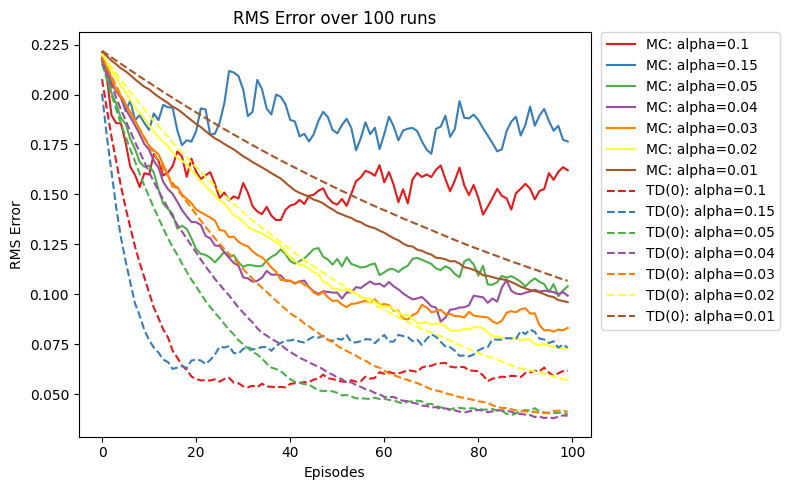

In [202]:
# plot the results
colors = plt.colormaps['tab10'].colors
colors = plt.colormaps['Set1'].colors
fig, ax = plt.subplots(figsize=(8, 5), tight_layout=False)
for i, alphas_1_ in enumerate(alphas_1):
    ax.plot(mc_rms_errors[i], label=f'MC: alpha={alphas_1_}', linestyle='-', color=colors[i])
for i, alphas_2_ in enumerate(alphas_2):
    ax.plot(td_rms_errors[i], label=f'TD(0): alpha={alphas_2_}', linestyle='--', color=colors[i])
ax.set_title('RMS Error over 100 runs')
ax.set_xlabel('Episodes')
ax.set_ylabel('RMS Error')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
fig.subplots_adjust(right=0.75)
plt.show()

## Batch Update


In [204]:
alpha = 0.05

In [205]:
# run mc with batch update
rms_mc = np.zeros(100)
for i in range(100):
    print(f'Run {i + 1}/100', end='\r')
    mc = MonteCarloControl(n_episodes=100, alpha=alpha)
    mc.run_batch_prediction()
    rms_mc += np.array(mc.rms_error)
rms_mc /= 100

In [206]:
# run TD(0) with batch update
rms_td0 = np.zeros(100)
for i in range(100):
    print(f'Run {i + 1}/100', end='\r')
    td0 = TD0(n_episodes=100, alpha=alpha)
    td0.run_batch_prediction()
    rms_td0 += np.array(td0.rms_error)
rms_td0 /= 100

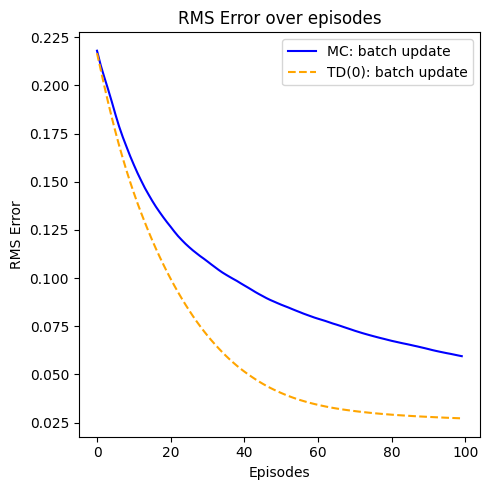

In [207]:
# plot the results
fig, ax = plt.subplots(figsize=(5, 5), tight_layout=True)
ax.plot(rms_mc, label=f'MC: batch update', linestyle='-', color='blue')
ax.plot(rms_td0, label=f'TD(0): batch update', linestyle='--', color='orange')
ax.set_title('RMS Error over episodes')
ax.set_xlabel('Episodes')
ax.set_ylabel('RMS Error')
ax.legend()
plt.show()